# 021-008. Image Files

*Open an image, inspect its raster structure, draw a high-contrast annotation, and save a separate result.*

The conceptual foundation is developed in Text and Structured File Round Trips.

## Method · Image Loading and Display

A raster image has a width, height, and color mode. A smaller preview keeps the notebook easy to scan without changing the source file.

The repository copy is `input/galapagos_penguin.jpg`. In JSPCV Playground, **Add files** stores it as `uploads/galapagos_penguin.jpg`; a Colab sidebar upload appears as `galapagos_penguin.jpg`. The code checks these locations in that order.

Mode: RGB
Size (width, height): (1280, 720)


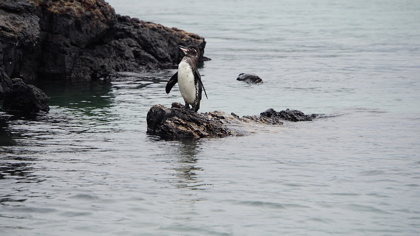

In [1]:
from pathlib import Path

from IPython.display import display
from PIL import Image

lesson_dir = Path.cwd()
local_path = Path("input/galapagos_penguin.jpg")
playground_path = Path("uploads/galapagos_penguin.jpg")
colab_path = Path("galapagos_penguin.jpg")

if local_path.exists():
    input_path = local_path
elif playground_path.exists():
    input_path = playground_path
else:
    input_path = colab_path

with Image.open(input_path) as source_image:
    image = source_image.convert("RGB")

preview = image.copy()
preview.thumbnail((420, 315))

print("Mode:", image.mode)
print("Size (width, height):", image.size)
display(preview)

## Implementation · Copy Annotation

Pixel coordinates follow `(left, top, right, bottom)`. Drawing on a copy preserves the decoded source image in memory.

Annotation bounds: (365, 75, 945, 690)


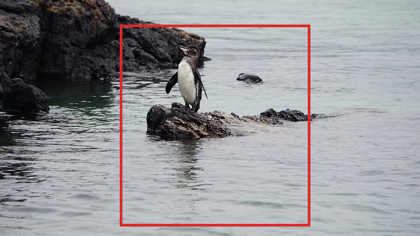

In [2]:
from PIL import ImageDraw

annotated = image.copy()
penguin_region = (365, 75, 945, 690)
draw = ImageDraw.Draw(annotated)
draw.rectangle(penguin_region, outline=(220, 40, 40), width=8)

annotated_preview = annotated.copy()
annotated_preview.thumbnail((420, 315))
print("Annotation bounds:", penguin_region)
display(annotated_preview)

## Implementation · Derived Image Output

The new filename keeps the transformed image separate from the original photograph.

In [3]:
output_dir = lesson_dir / "output"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "galapagos_penguin_annotated.jpg"
annotated.save(output_path, format="JPEG", quality=90)

print("Saved:", output_path.relative_to(lesson_dir))
print("Encoded bytes:", output_path.stat().st_size)

Saved: output/galapagos_penguin_annotated.jpg
Encoded bytes: 217949


### Interpretation · Derived Image Output

The red rectangle changes pixels only in `annotated`. Saving compresses that derived raster as JPEG while the original file remains unchanged.

### Independent Practice · Your Turn

Test how annotation width affects visibility while preserving the source image. Change the rectangle `width` from `8` to `4`, save the new figure as `output/galapagos_penguin_thin_box.jpg`, and display it. Explain the displayed difference in one or two sentences.